In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks',
    '/home/export/soheuny/SRFinder/soheun/notebooks/draft'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("/home/export/soheuny/SRFinder/soheun")

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

mpl.rc("text", usetex=True)
# mpl.rcParams["text.latex.preamble"] = (
#     r'\usepackage{helvet}'
#     r'\usepackage{sansmath}'
#     r'\sansmath'
# )

plt.rcParams['axes.labelsize'] = 30
plt.rcParams['figure.labelsize'] = 30
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 25
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 20
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

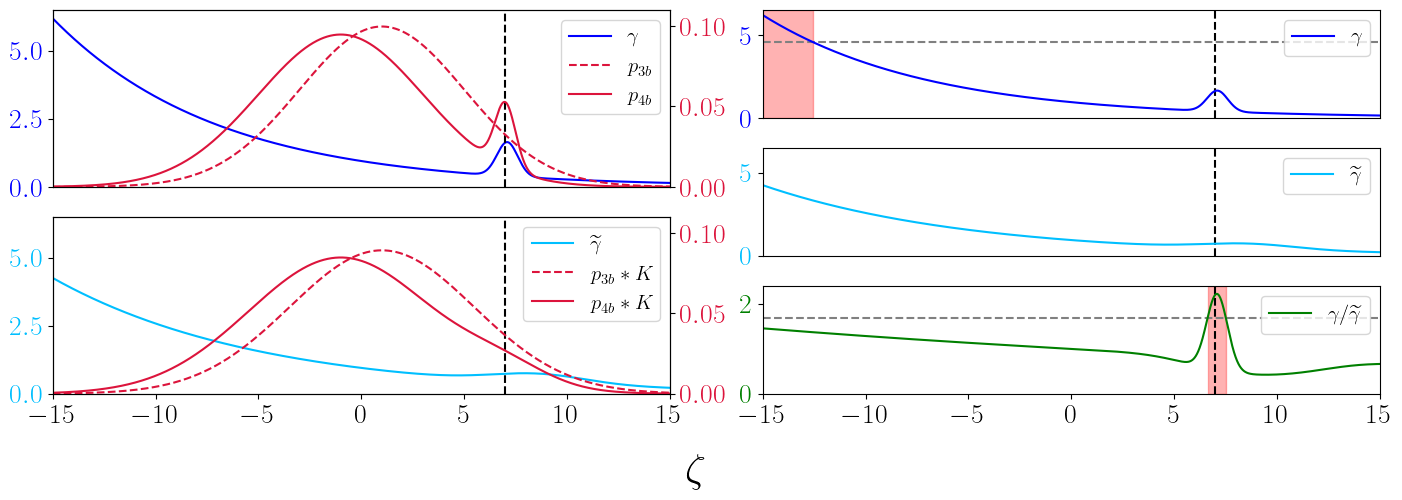

In [3]:
plt.rcParams['legend.fontsize'] = 15


# P_3b: Gaussian distribution N(0, 1)
# P_4b: Gaussian distribution N(0.1, 1) 
# Signal: Gaussian distribution N(1, 0.1)


# Generate data
np.random.seed(0)
mu_3b, sigma_3b = 1, 4
mu_4b, sigma_4b = -1, 4
mu_s, sigma_s = 7, 0.5

signal_ratio = 0.05
n_samples = 100000

P_3b_samples = np.random.normal(mu_3b, sigma_3b, n_samples)
B_4b_samples = np.random.normal(mu_4b, sigma_4b, n_samples - int(n_samples * signal_ratio))
signal_samples = np.random.normal(mu_s, sigma_s, int(n_samples * signal_ratio))

# Plot histograms
# nbins = 50
# all_samples = np.concatenate([P_3b_samples, B_4b_samples, signal_samples])
# bins = np.linspace(all_samples.min(), all_samples.max(), nbins)
# plt.figure(figsize=(15, 9))
# plt.hist(P_3b_samples, bins=bins, histtype='step', label="3b")
# plt.hist(B_4b_samples, bins=bins, histtype='step', label="bg4b")
# plt.hist(signal_samples, bins=bins, histtype='step', label="signal")
# plt.legend()
# plt.show()

# pdf of P_3b
# x = np.linspace(all_samples.min(), all_samples.max(), 10000)

x = np.linspace(-15, 15, 10000)

smear_sigma = 2


pdf_P_3b = stats.norm.pdf(x, mu_3b, sigma_3b)
pdf_B_4b = stats.norm.pdf(x, mu_4b, sigma_4b)
pdf_signal = stats.norm.pdf(x, mu_s, sigma_s)
pdf_P_4b = (1 - signal_ratio) * pdf_B_4b + signal_ratio * pdf_signal

pdf_P_3b_smeared = stats.norm.pdf(x, mu_3b, np.sqrt(sigma_3b**2 + smear_sigma**2))
pdf_B_4b_smeared = stats.norm.pdf(x, mu_4b, np.sqrt(sigma_4b**2 + smear_sigma**2))
pdf_signal_smeared = stats.norm.pdf(x, mu_s, np.sqrt(sigma_s**2 + smear_sigma**2))
pdf_P_4b_smeared = (1 - signal_ratio) * pdf_B_4b_smeared + signal_ratio * pdf_signal_smeared

grid = GridSpec(6, 2)
fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot(grid[:3, 0])
fig.supxlabel(r"$\zeta$")

xlim = (-15, 15)
ylim = (0, 0.11)

ax.set_xlim(xlim)
ax.plot(x, pdf_P_4b / pdf_P_3b, label=r"$\gamma$", color='blue')
for label in ax.get_yticklabels():
    label.set_color('blue')

ax2 = plt.gca().twinx()
ax2.set_ylim(ylim)   
ax2.axvline(mu_s, linestyle="--", color="k")
ax2.plot(x, pdf_P_3b, label=r"$p_{3b}$", color="crimson", linestyle="--")
ax2.plot(x, pdf_P_4b, label=r"$p_{4b}$", color="crimson")
# ax2 tick labels to m color
for label in ax2.get_yticklabels():
    label.set_color("crimson")
    

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles + handles2, labels + labels2, loc='upper right')
ax.set_xticks([])
ax2.set_xticks([])
ax.set_ylim(0, 6.5)

ax = fig.add_subplot(grid[3:, 0])
ax.set_xlim(xlim)
ax.plot(x, pdf_P_4b_smeared / pdf_P_3b_smeared, label=r"$\widetilde{\gamma}$", color="deepskyblue")
for label in ax.get_yticklabels():
    label.set_color("deepskyblue")


ax2 = plt.gca().twinx()
ax2.set_ylim(ylim)
ax2.axvline(mu_s, linestyle="--", color="k")
ax2.plot(x, pdf_P_3b_smeared, label=r"$p_{3b} * K$", color="crimson", linestyle="--")
ax2.plot(x, pdf_P_4b_smeared, label=r"$p_{4b} * K$", color="crimson")
for label in ax2.get_yticklabels():
    label.set_color("crimson")
ax.set_ylim(0, 6.5)

# merge ax and ax2 legends

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles + handles2, labels + labels2, loc='upper right')

ylim = (0, 6.5)

ax = fig.add_subplot(grid[0:2, 1])
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.axvline(mu_s, linestyle="--", color="k")
y_thrs = 0.7 * (ylim[1] - ylim[0]) + ylim[0]
ax.axhline(y_thrs, linestyle="--", color="gray")
ax.plot(x, pdf_P_4b / pdf_P_3b, label=r"$\gamma$", color='blue')
# red shaded region
# find a point where pdf_P_4b / pdf_P_3b = y_thrs
idx = np.argmin(np.abs(pdf_P_4b / pdf_P_3b - y_thrs))
x_thrs = x[idx]
ax.fill_between([xlim[0], x_thrs], ylim[0], ylim[1], color="red", alpha=0.3)
for label in ax.get_yticklabels():
    label.set_color('blue')
ax.legend(loc='upper right')
ax.set_xticks([])

ax = fig.add_subplot(grid[2:4, 1])
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.axvline(mu_s, linestyle="--", color="k")
ax.plot(x, pdf_P_4b_smeared / pdf_P_3b_smeared, label=r"$\widetilde{\gamma}$", color="deepskyblue")
for label in ax.get_yticklabels():
    label.set_color("deepskyblue")
ax.legend(loc='upper right')
ax.set_xticks([])

ylim = (0, 2.4)
ax = fig.add_subplot(grid[4:, 1])
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.axvline(mu_s, linestyle="--", color="k")
y_thrs = 0.7 * (ylim[1] - ylim[0]) + ylim[0]
ax.axhline(y_thrs, linestyle="--", color="gray")
# red shaded region
# find two points where (pdf_P_4b / pdf_P_3b) / (pdf_P_4b_smeared / pdf_P_3b_smeared) = y_thrs
left_to_mu_s = x < mu_s
right_to_mu_s = x > mu_s
diff = (pdf_P_4b / pdf_P_3b) / (pdf_P_4b_smeared / pdf_P_3b_smeared) - y_thrs
x_thrs_smaller = x[left_to_mu_s][np.argmin(np.abs(diff[left_to_mu_s]))]
x_thrs_larger = x[right_to_mu_s][np.argmin(np.abs(diff[right_to_mu_s]))]
ax.fill_between([x_thrs_smaller, x_thrs_larger], ylim[0], ylim[1], color="red", alpha=0.3)
ax.plot(x, (pdf_P_4b / pdf_P_3b) / (pdf_P_4b_smeared / pdf_P_3b_smeared), label=r"$\gamma / \widetilde{\gamma}$", color='green')
for label in ax.get_yticklabels():
    label.set_color('green')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("figures/smear_toy.pdf", dpi=300)
plt.show()
plt.close()

In [4]:
x_range = np.linspace(-1, 1, 100000)

def bump(x, loc=0, scale=1):
    assert scale > 0
    return np.where(
        (x < loc + scale) & (x > loc - scale),
        np.cos((x - loc) * np.pi / (2 * scale)),
        0
    )
n_bumps = 10
total_weight = 0.02
s1 = 1 / (2 * n_bumps)
s2 = 1/2
spreaded = 0.75
CR_x = 0.04

def routine(n_bumps, total_weight, s1, s2, s3, spreaded, CR_x):
    in_CR_x = np.abs(x_range) > CR_x
    in_SR_x = np.abs(x_range) <= CR_x
    y_spread = 1 + np.sum([
    spreaded * bump(x_range, loc= 2 * i / n_bumps - 1, 
            scale=s1) * (total_weight / (s1 * n_bumps))
        for i in range(n_bumps + 1)
    ], axis=0)
    y_spread = y_spread + (1 - spreaded) * bump(x_range, loc=0, scale=s3) * (total_weight / s3)
    interp_spread = 1 + (1 - spreaded) * bump(x_range, loc=0, scale=s3) * (total_weight / s3)
    y_concentrated = 1 + bump(x_range, loc=0, scale=s2) * (total_weight / s2)

    print((np.mean(y_spread[in_CR_x]) - 1) / total_weight, (np.mean(y_concentrated[in_CR_x]) - 1) / total_weight)
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

    ax[0].plot(x_range, y_spread)
    ax[1].plot(x_range, y_concentrated)
    for a in ax:
        a.set_xlim(-1, 1)
        a.set_ylim(0.9, 1.2)
        # fill CR region as red
        ylim = a.get_ylim()
        a.fill_between([-CR_x, CR_x], ylim[0], ylim[1], color="red", alpha=0.3, label="SR")
        a.axhline(1, color=plt.cm.tab10.colors[0], linestyle="--", label="background")
        a.legend()
    ax[0].plot(x_range[in_SR_x], interp_spread[in_SR_x], color="crimson")
    ax[1].plot(x_range[in_SR_x], y_concentrated[in_SR_x], color="crimson")

    plt.show()

0.6366234055676934 0.038944507156202235


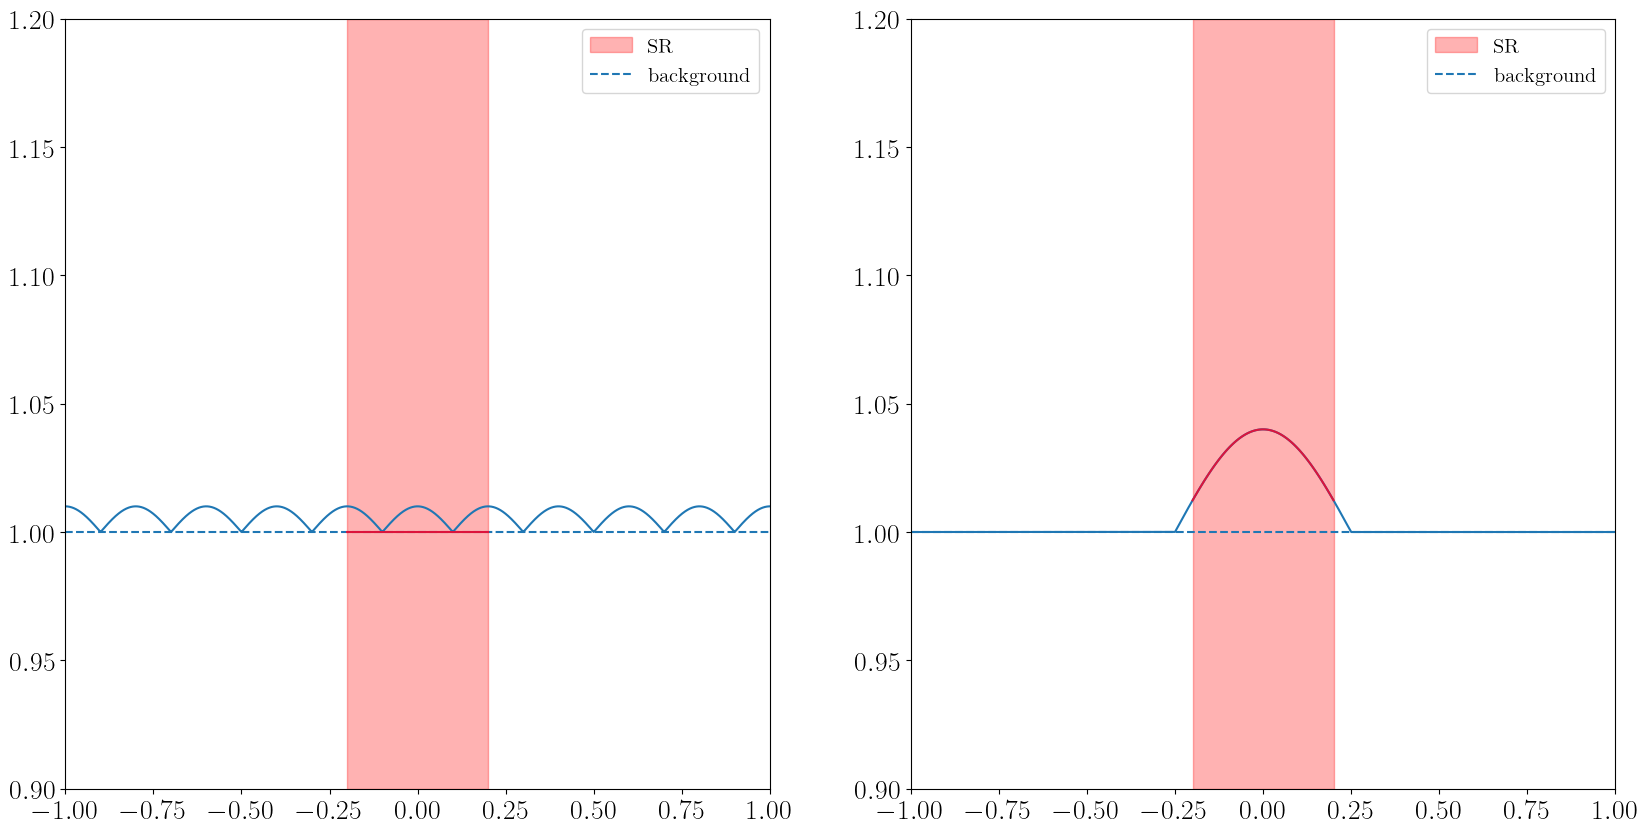

In [5]:
n_bumps = 10
total_weight = 0.01
s1 = 1 / (n_bumps)
s2 = 1/4
s3 = 1
spreaded = 1.0
CR_x = 0.2

routine(n_bumps, total_weight, s1, s2, s3, spreaded, CR_x)


In [14]:
x_range = np.linspace(-2, 2, 100000)

def bump(x, loc=0, scale=1):
    assert scale > 0
    return np.where(
        (x < loc + scale) & (x > loc - scale),
        np.cos((x - loc) * np.pi / (2 * scale)),
        0
    )

def routine(total_signal, s1, s2, CR_spread):
    in_CR_spread = np.abs(x_range) > CR_spread
    in_SR_spread = np.abs(x_range) <= CR_spread
    CR_concentrated = CR_spread * (s2 / s1)
    in_CR_concentrated = np.abs(x_range) > CR_concentrated
    in_SR_concentrated = np.abs(x_range) <= CR_concentrated
    
    y_spread = 1 + bump(x_range, loc=0, scale=s1) * (total_signal * np.pi / s1)
    y_concentrated = 1 + bump(x_range, loc=0, scale=s2) * (total_signal * np.pi / s2)

    print(np.sum(y_spread[in_CR_spread] - 1) / np.sum(y_spread - 1), 
          np.sum(y_concentrated[in_CR_concentrated] - 1) / np.sum(y_concentrated - 1))
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(19, 5))

    ax[0].set_ylabel(r"Density")
    ax[0].plot(x_range, y_spread, label="4b (Including Signal)")
    ax[1].plot(x_range, y_concentrated, label="4b (Including Signal)")
    for a in ax:
        a.set_xlim(-1, 1)
        a.set_ylim(0.95, 1.2)
        # fill CR region as red
        ylim = a.get_ylim()
        a.axhline(1, color=plt.cm.tab10.colors[1], linestyle="--", label="Background 4b = 3b")
    ax[0].plot(x_range[in_SR_spread], y_spread[in_SR_spread], color="crimson", 
               label="Estimated Background 4b")
    ax[0].fill_between([-CR_spread, CR_spread], ylim[0], ylim[1], color="red", alpha=0.3, label="SR")
    ax[0].set_xlabel(r"$x$")
    ax[0].fill_between(x_range[x_range < -CR_spread], 1, y_spread[x_range < -CR_spread], 
                       color="gray", alpha=0.5, hatch='/', label="Contamination")
    ax[0].fill_between(x_range[x_range > CR_spread], 1, y_spread[x_range > CR_spread], 
                       color="gray", alpha=0.5, hatch='/')
    ax[1].plot(x_range[in_SR_concentrated], y_concentrated[in_SR_concentrated], color="crimson", 
               label="Estimated Background 4b")
    ax[1].fill_between([-CR_concentrated, CR_concentrated], ylim[0], ylim[1], color="red", alpha=0.3, label="SR")
    ax[1].set_xlabel(r"$\zeta$")
    ax[1].fill_between(x_range[x_range < -CR_concentrated], 1, y_concentrated[x_range < -CR_concentrated], 
                       color="gray", alpha=0.5, label="Contamination", hatch='/')
    ax[1].fill_between(x_range[x_range > CR_concentrated], 1, y_concentrated[x_range > CR_concentrated], 
                       color="gray", alpha=0.5, hatch='/')
    for a in ax:
        a.legend(fontsize=17.5)
    plt.tight_layout()
    plt.savefig("figures/on_which_to_learn_toy.pdf", dpi=300)
    plt.show()


0.4122096643920875 0.4122604920646573


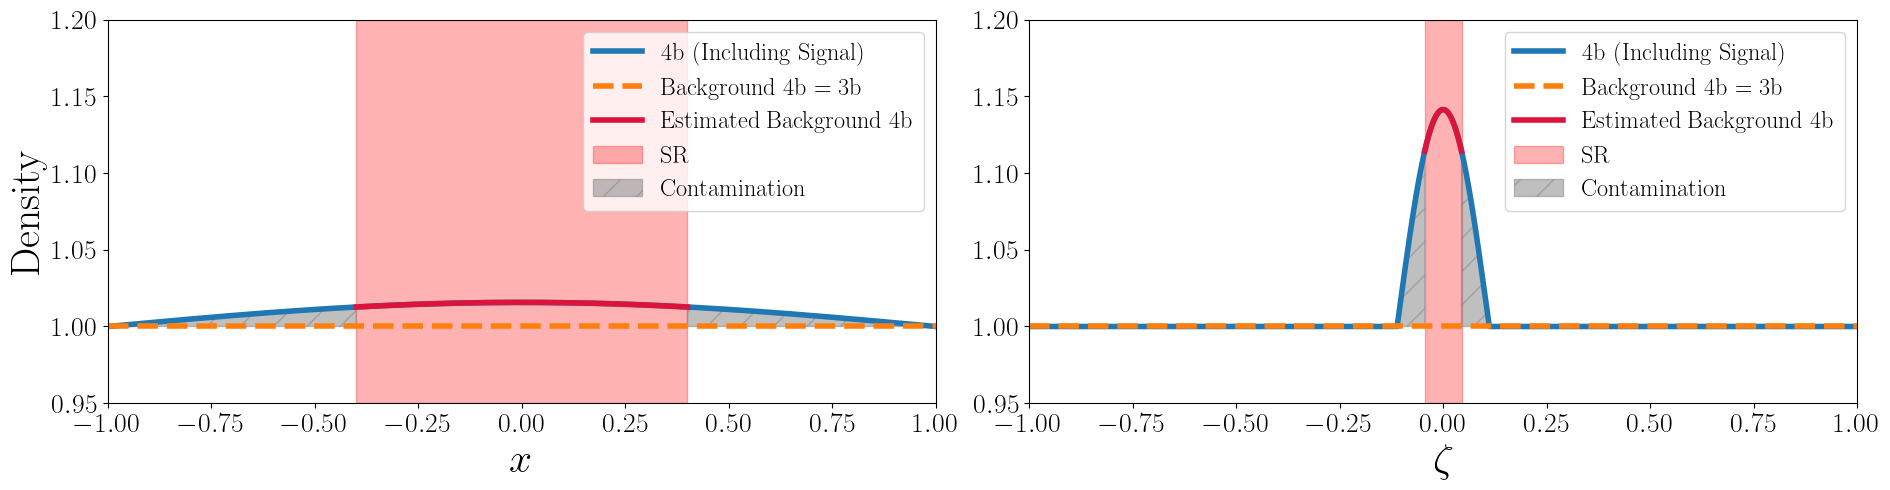

In [15]:
total_weight = 0.005
s1 = 1
s2 = 1/9
CR_spread = 0.4

plt.rcParams['lines.linewidth'] = 4
routine(total_weight, s1, s2, CR_spread)